# **Start**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import auth
auth.authenticate_user()

import requests

gcloud_token = !gcloud auth print-access-token
gcloud_tokeninfo = requests.get('https://www.googleapis.com/oauth2/v3/tokeninfo?access_token=' + gcloud_token[0]).json()
user_email = gcloud_tokeninfo['email']

# Now compare the email
if user_email == 'saimons.5c@gmail.com':
    path = "drive/MyDrive/Work/08_BOXES/Notebooks"
else:
    path = "drive/MyDrive/Notebooks"

print(f"Assigned path: {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Assigned path: drive/MyDrive/Notebooks


In [ ]:
!pip install gpytorch
import gpytorch

!pip install hist
import hist

import json

!pip install lmfit
from lmfit import Parameters
from lmfit.models import PolynomialModel, GaussianModel

import matplotlib.pyplot as plt
plt.style.use("bmh")

import numpy as np
np.set_printoptions(precision=3, linewidth=400, suppress=True)

from scipy import interpolate

import os, sys

import sqlite3

import torch

from tqdm.notebook import tqdm

from uncertainties import unumpy

In [ ]:
def make_fit(x, y, ax=None):

    ind = np.where(y > 0)[0]
    x = x[ind]
    y = y[ind]

    params, model = setup_params()
    result = model.fit(y, params, x=x, weights=1/np.sqrt(y))

    x_i = np.linspace(x[0], x[-1], 1000)
    fit_i = model.eval(result.params, x=x_i)
    components = result.eval_components(x=x_i)

    for key in components.keys():
        ax.plot(x_i, components[key], lw=1)

    ax.plot(x_i, fit_i, c='r')
    width = np.diff(x)[0]


    return result

def make_plot(centers, counts, table_name, duration=2, nframes=150, show=True):

    ind = np.where(counts > 0)[0]
    x = centers[ind]
    y = counts[ind]

    fig, ax = plt.subplots(figsize=(7,4), nrows=1, ncols=1, dpi=100)
    ax.grid(ls=":")
    ax.set_axisbelow(True)

    ax.step(centers, counts, where='mid', c='k', lw=1)
    result = make_fit(x, y, ax)

    width = np.diff(centers)[0]
    time = duration * nframes
    if int(table_name.split('rot')[-1].split('_')[0])/100 > 74.:
        RKa = 0
        errRKa = 0
    else:
        RKa = result.params['Fe_Ka_amplitude'].value / time / width
        errRKa = result.params['Fe_Ka_amplitude'].stderr / time / width
    Rate = unumpy.uarray(counts, np.sqrt(counts)).sum() / time
    Rtot, errRtot = Rate.nominal_value, Rate.std_dev

    ax.set_title(
        fr'{table_name[2:]}',
    )

    textstr = '\n'.join((
        fr'χ$^\mathregular{{2}}$/ndf = {result.redchi:.2f}',
        fr'R(FeKα) = {RKa:.1f}$\pm${errRKa:.1f} Hz',
        fr'R$\mathregular{{_{{tot}}}}$ = {Rtot:.1f}$\pm${errRtot:.1f} Hz',
    ))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10, va='top', bbox=props)

    ax.set_xlim(50,500)
    ax.set_xlabel('Channels')
    ax.set_ylim(0,200)#counts.max()*1.2)
    ax.set_ylabel(f'Counts / {width:.0f} Channels')
    plt.tight_layout()
    if show:
        print(result.fit_report(show_correl=False))
        plt.show()
    plt.close()

    return Rtot, errRtot, RKa, errRKa

def setup_params():

    params = Parameters()

    params.add('c0', value=1)
    params.add('c1', value=0.1)
    params.add('c2', value=0.01)
    params.add('Fe_Ka_amplitude', value=1e3, min=0)
    params.add('Fe_Ka_center', value=280, min=200, max=350)
    params.add('Fe_Ka_sigma', value=12, min=0, max=500)

    model = PolynomialModel(degree=2)
    model += GaussianModel(prefix='Fe_Ka_')

    return params, model

def load_database(dbfile):

    conn = sqlite3.connect(dbfile)
    conn.row_factory = sqlite3.Row
    cursor = conn.cursor()

    return cursor

def load_spectrum(cursor, nhits=10, rebin=1):

    counts_i = np.array([np.frombuffer(row["counts"], dtype=np.uint8) for row in cursor.fetchall() if np.frombuffer(row["counts"], dtype=np.uint8).sum() < nhits])
    nframes = counts_i.shape[0]

    counts = np.sum(counts_i, axis=0)
    bins = np.arange(641)

    histogram = hist.Hist(
        hist.axis.Variable(bins, name="x")
    )
    centers = histogram.axes[0].centers

    repeated_centers = np.repeat(centers, counts.astype(int))

    histogram.fill(x=repeated_centers)
    histogram = histogram[::hist.rebin(rebin)]

    counts = histogram.values()
    counts = np.array(counts, dtype=int)
    centers = histogram.axes[0].centers

    return centers, counts, nframes

# 1-Fit

[[Model]]
    (Model(polynomial) + Model(gaussian, prefix='Fe_Ka_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 50
    # data points      = 309
    # variables        = 6
    chi-square         = 521.195595
    reduced chi-square = 1.72011747
    Akaike info crit   = 173.540292
    Bayesian info crit = 195.940340
    R-squared          = 0.95763007
[[Variables]]
    c0:               2.37162359 +/- 0.34469979 (14.53%) (init = 1)
    c1:               0.00117544 +/- 0.00283159 (240.90%) (init = 0.1)
    c2:              -3.5801e-07 +/- 4.5051e-06 (1258.39%) (init = 0.01)
    Fe_Ka_amplitude:  3889.38696 +/- 119.935611 (3.08%) (init = 1000)
    Fe_Ka_center:     280.489997 +/- 0.39319433 (0.14%) (init = 280)
    Fe_Ka_sigma:      12.1686738 +/- 0.30827461 (2.53%) (init = 12)


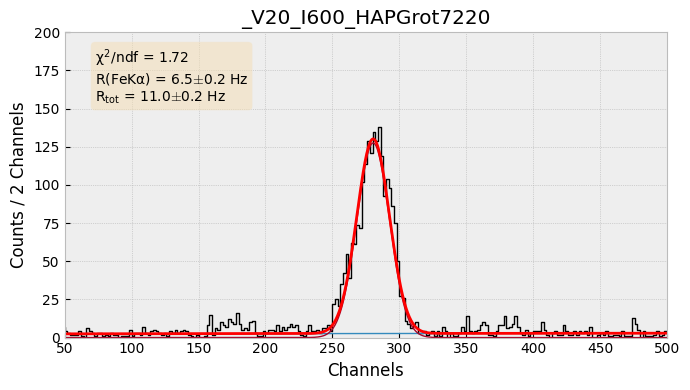

In [ ]:
def plot_single(table_name='Fe_V20_I600_HAPGrot7220'):

    cursor = load_database(dbfile=f'{path}/HAPGrot_Scan.db')
    cursor.execute(f'SELECT * FROM {table_name};')
    centers, counts, nframes = load_spectrum(cursor, nhits=500, rebin=2)
    make_plot(centers, counts, table_name)

plot_single()

In [ ]:
def fit_all():
    #path = "drive/MyDrive/Work/08_BOXES/Notebooks"
    cursor = load_database(dbfile=f'{path}/HAPGrot_Scan.db')
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    # Fetch all the tables
    tables = cursor.fetchall()
    # Extract table names from the result
    table_names = np.array([table[0] for table in tables if 'rot' in table[0]])[:]
    values = [int(table_name.split('rot')[-1].split('_')[0]) for table_name in table_names]

    rot_n = [int(table_name.split('rot')[-1].split('_')[0])/100 for table_name in table_names]
    Rtot_n = []
    errRtot_n = []
    RKa_n = []
    errRKa_n = []

    for table_name in tqdm(table_names):
        cursor.execute(f'SELECT * FROM {table_name};')
        centers, counts, nframes = load_spectrum(cursor, nhits=40, rebin=2)
        Rtot, errRtot, RKa, errRKa = make_plot(centers, counts, table_name, show=False)

        #print(f"{table_name}: Rtot = {Rtot:5.2f}, errRtot = {errRtot:4.2f}, RKa = {RKa:5.2f}, errRKa = {errRKa:4.2f}")

        Rtot_n.append(Rtot)
        errRtot_n.append(errRtot)
        RKa_n.append(RKa)
        errRKa_n.append(errRKa)

    return rot_n, Rtot_n, errRtot_n

rot_n, Rtot_n, errRtot_n = fit_all()

  0%|          | 0/61 [00:00<?, ?it/s]

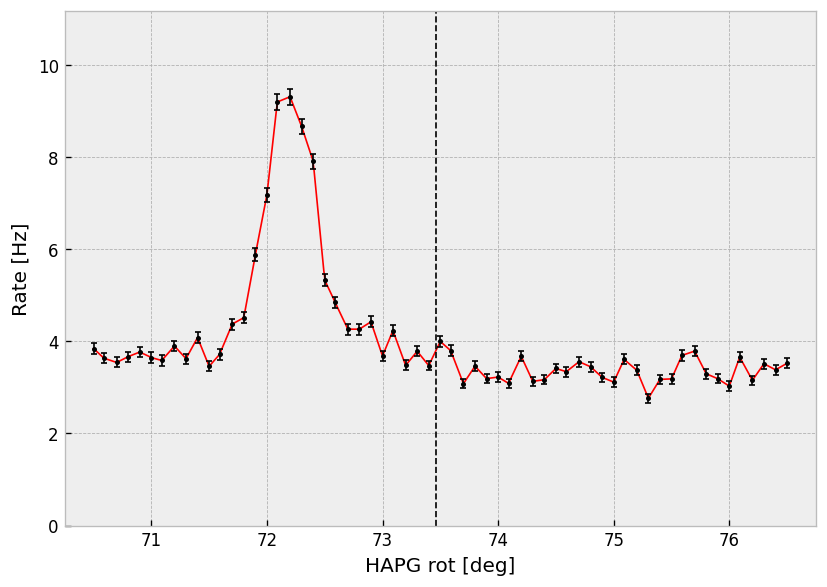

In [ ]:
def plot_scan(x, y, err_y):

    f = interpolate.interp1d(x, y, kind='linear')

    # Linspace to generate interpolated data (optional, for your reference)
    x_i = np.linspace(x[0], x[-1], 501)
    y_i = f(x_i)

    def objective_function(x):
        # Convert x to numpy array if it's a PyTorch tensor
        if isinstance(x, torch.Tensor):
            x = x.detach().numpy()
            return torch.tensor(f(x).squeeze(-1), dtype=torch.double)
        else:
            return f(x)

    fig, ax = plt.subplots(figsize=(7,5), nrows=1, ncols=1, dpi=120)

    ax.plot(x_i, y_i, c='r', lw=1, label='interpolation')
    ax.errorbar(rot_n, Rtot_n, errRtot_n, fmt='o', c='k', ms=2, lw=1, capsize=2)
    ax.set_ylabel(f'Rate [Hz]')
    ax.set_ylim(0,Rtot_n.max()*1.2)


    ax.axvline(73.46, c='k', lw=1, ls='--')
    #ax.set_xlim(rot_n[0]-0.01/2,rot_n[-1]+0.01/2)
    ax.set_xlim(70.25,76.75)
    ax.set_xlabel('HAPG rot [deg]')

    plt.tight_layout()

Rtot_n = np.array(Rtot_n)[np.argsort(rot_n)]
errRtot_n = np.array(errRtot_n)[np.argsort(rot_n)]
rot_n = np.sort(rot_n)

x = rot_n
y = Rtot_n
err_y = errRtot_n

plot_scan(x, y, err_y)

In [ ]:
likelihood_score = []
trained_likelihood_score = []

# 2-GP Zero Mean + RBF Kernel

In [ ]:
train_x = torch.tensor(x, dtype=torch.float)
train_y = torch.tensor(y, dtype=torch.float)
err_train_y = torch.tensor(err_y, dtype=torch.float)
xt_i = torch.linspace(70., 77, 301).unsqueeze(1)

class BaseGPModel(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_GP(model, likelihood, training_iter=200):
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam([
        {'params': model.covar_module.parameters()},
        {'params': model.likelihood.parameters()}
    ], lr=0.25)

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    lengthscales = []
    outputscales = []
    noises = []

    for i in tqdm(range(training_iter)):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()

        losses.append(loss.item())
        lengthscales.append(model.covar_module.base_kernel.lengthscale.item())
        outputscales.append(model.covar_module.outputscale.item())
        noises.append(model.likelihood.noise.item())

        optimizer.step()

    model.eval()
    likelihood.eval()

    return losses, noises, lengthscales, outputscales

def plot_train_GP(losses, noises, lengthscales, outputscales):

    fig, axes = plt.subplots(figsize=(4*2,2.5*2), nrows=2, ncols=2, dpi=110)

    ax = axes[0,0]
    ax.plot(losses)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

    ax = axes[0,1]
    ax.plot(noises)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise')

    ax = axes[1,0]
    ax.plot(lengthscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Lengthscale')

    ax = axes[1,1]
    ax.plot(outputscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Outputscale')

    plt.tight_layout()

def fit_GP(
        train_x,
        train_y,
        train=True,
        plot_train=False,
        training_iter=200):

    noise = 1e-1
    lengthscale = 0.1
    outputscale = 10.

    # initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    #likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(noise=err_train_y, learn_additional_noise=True)
    model = BaseGPModel(train_x, train_y, likelihood)
    model.likelihood.noise = noise

    # Fix the hyperparameters
    model.covar_module.base_kernel.lengthscale = lengthscale
    model.covar_module.outputscale = outputscale

    model.eval()
    likelihood.eval()

    if train:
        losses, noises, lengthscales, outputscales = train_GP(model, likelihood, training_iter)
        if plot_train:
            plot_train_GP(losses, noises, lengthscales, outputscales)

    return model, likelihood

def visualize_GP(model, likelihood, policy=None, next_x=None):

    with torch.no_grad():
        predictive_distribution = likelihood(model(xt_i))
        predictive_mean = predictive_distribution.mean
        predictive_lower, predictive_upper = predictive_distribution.confidence_region()

        torch.manual_seed(0)
        samples = predictive_distribution.sample(torch.Size([5]))

        if policy is not None:
            acquisition_score = policy(xt_i.unsqueeze(1))

    fig, ax = plt.subplots(figsize=(6,4), nrows=1, ncols=1, dpi=130)

    if next_x is not None:
        ax.axvline(next_x.item(), c='r', lw=1, ls='--')

    ax.axvline(73.46, c='k', lw=1, ls='--')
    ax.plot(xt_i, predictive_mean, label="mean")
    ax.fill_between(
        xt_i.flatten(), predictive_upper, predictive_lower, alpha=0.3, label="95% CI"
    )

    #for i in range(1, samples.shape[0]):
    #    ax.plot(xt_i, samples[i, :], alpha=0.5, lw=1)

    ax.errorbar(x, y, err_y, fmt='o', ms=2, c='k', lw=1, capsize=1, label='data')

    ax.set_ylim(0,12)
    ax.set_ylabel(r'Rate [Hz]')
    ax.set_title(r'Total Rate')

    ax.set_xlim(70.25,76.75)
    ax.legend()
    ax.set_axisbelow(True)
    ax.set_xlabel('HAPGrot [deg]')

    plt.tight_layout()

def fit_estimation(model, likelihood):

  model.train()
  likelihood.train()

  with torch.no_grad():
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    output = model(train_x)
    score = mll(output, train_y)

  print('Likelihood score = ', score.detach().numpy())

  model.eval()
  likelihood.eval()

  return score.detach().numpy()

Likelihood score =  -2.1548076


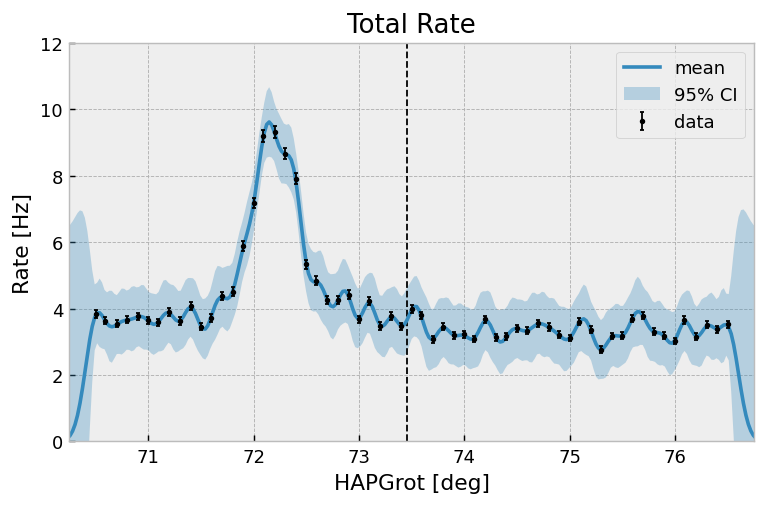

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=False)

visualize_GP(model, likelihood)


likelihood_score.append(fit_estimation(model, likelihood))

  0%|          | 0/200 [00:00<?, ?it/s]

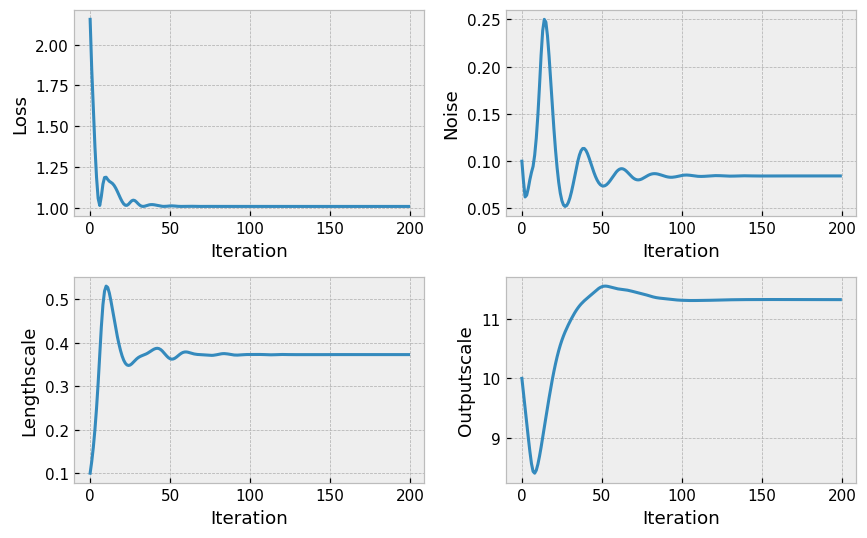

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=True, plot_train=True, training_iter=200)

Likelihood score =  -1.0074736


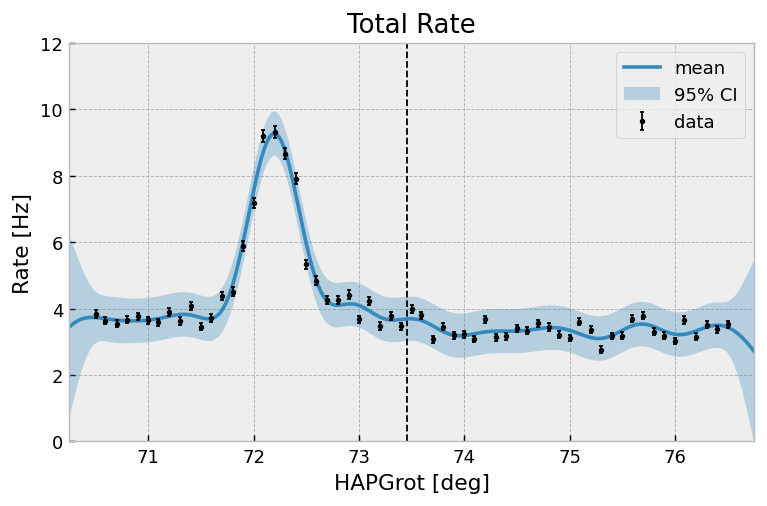

In [ ]:
visualize_GP(model, likelihood)
trained_likelihood_score.append(fit_estimation(model, likelihood))

# 3-GP Constant Mean + RBF Kernel

In [ ]:
class ConstantGPModel(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_GP(model, likelihood, training_iter=200):
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam([
        {'params': model.covar_module.parameters()},
        {'params': model.likelihood.parameters()},
        {'params': model.mean_module.constant}
    ], lr=0.25)

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    lengthscales = []
    outputscales = []
    noises = []
    constants = []

    for i in tqdm(range(training_iter)):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()

        losses.append(loss.item())
        lengthscales.append(model.covar_module.base_kernel.lengthscale.item())
        outputscales.append(model.covar_module.outputscale.item())
        noises.append(model.likelihood.noise.item())
        constants.append(model.mean_module.constant.item())

        optimizer.step()

    model.eval()
    likelihood.eval()

    return losses, noises, lengthscales, outputscales, constants

def plot_train_GP(losses, noises, lengthscales, outputscales, constants):

    fig, axes = plt.subplots(figsize=(4*2,2.5*2), nrows=2, ncols=3, dpi=110)

    ax = axes[0,0]
    ax.plot(losses)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

    ax = axes[0,1]
    ax.plot(noises)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise')

    ax = axes[1,0]
    ax.plot(lengthscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Lengthscale')

    ax = axes[1,1]
    ax.plot(outputscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Outputscale')

    ax = axes[1,2]
    ax.plot(constants)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Constant')

    plt.tight_layout()

def fit_GP(
        train_x,
        train_y,
        train=True,
        plot_train=False,
        training_iter=200):

    noise = 1e-1
    lengthscale = 0.1
    outputscale = 10.

    # initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = ConstantGPModel(train_x, train_y, likelihood)
    model.likelihood.noise = noise

    # Fix the hyperparameters
    model.covar_module.base_kernel.lengthscale = lengthscale
    model.covar_module.outputscale = outputscale

    model.eval()
    likelihood.eval()

    if train:
        losses, noises, lengthscales, outputscales, constants = train_GP(model, likelihood, training_iter)
        if plot_train:
            plot_train_GP(losses, noises, lengthscales, outputscales, constants)

    return model, likelihood

Likelihood score =  -2.1548076


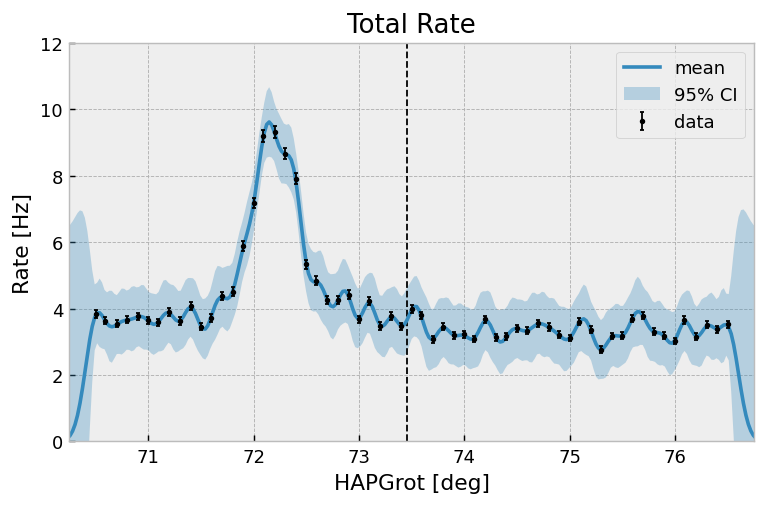

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=False)
likelihood_score.append(fit_estimation(model, likelihood))

visualize_GP(model, likelihood)

  0%|          | 0/200 [00:00<?, ?it/s]

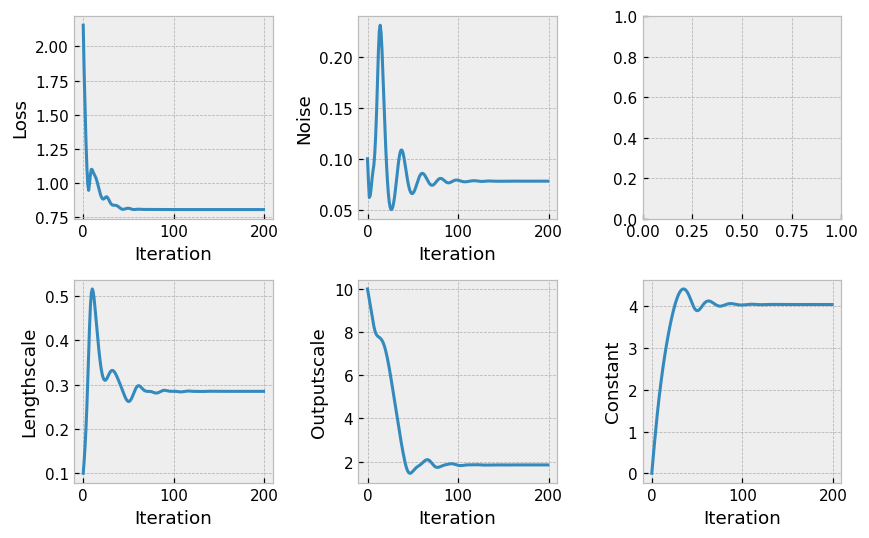

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=True, plot_train=True, training_iter=200)



Likelihood score =  -0.80486447


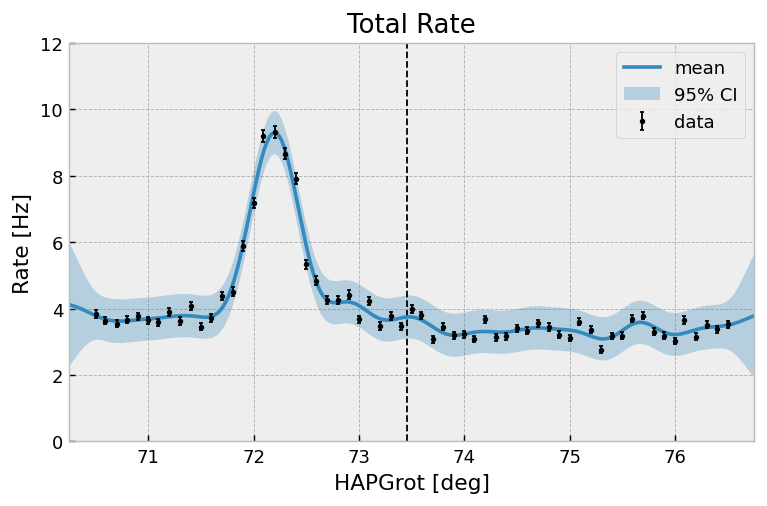

In [ ]:
visualize_GP(model, likelihood)
trained_likelihood_score.append(fit_estimation(model, likelihood))

# 4-GP Linear Mean + RBF Kernel #

In [ ]:
class LinearGPModel(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.LinearMean(1)
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_GP(model, likelihood, training_iter=200):
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam([
        {'params': model.covar_module.parameters()},
        {'params': model.likelihood.parameters()},
        {'params': model.mean_module.parameters()}
    ], lr=0.25)

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    lengthscales = []
    outputscales = []
    noises = []
    weights = []
    biases = []

    for i in tqdm(range(training_iter)):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x) #####
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()

        losses.append(loss.item())
        lengthscales.append(model.covar_module.base_kernel.lengthscale.item())
        outputscales.append(model.covar_module.outputscale.item())
        noises.append(model.likelihood.noise.item())
        weights.append(model.mean_module.weights.item())
        biases.append(model.mean_module.bias.item())

        optimizer.step()

    model.eval()
    likelihood.eval()

    return losses, noises, lengthscales, outputscales, weights, biases

def plot_train_GP(losses, noises, lengthscales, outputscales, weights, biases):

    fig, axes = plt.subplots(figsize=(4*2,2.5*2), nrows=2, ncols=3, dpi=110)

    ax = axes[0,0]
    ax.plot(losses)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

    ax = axes[0,1]
    ax.plot(noises)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise')

    ax = axes[0,2]
    ax.plot(weights)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Weight')

    ax = axes[1,0]
    ax.plot(lengthscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Lengthscale')

    ax = axes[1,1]
    ax.plot(outputscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Outputscale')

    ax = axes[1,2]
    ax.plot(biases)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Bias')

    plt.tight_layout()

def fit_GP(
        train_x,
        train_y,
        train=True,
        plot_train=False,
        training_iter=200):

    noise = 1e-1
    lengthscale = 0.1
    outputscale = 10.

    # initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = LinearGPModel(train_x, train_y, likelihood)
    model.likelihood.noise = noise

    # Fix the hyperparameters
    model.covar_module.base_kernel.lengthscale = lengthscale
    model.covar_module.outputscale = outputscale

    model.eval()
    likelihood.eval()

    if train:
        losses, noises, lengthscales, outputscales, weights, biases = train_GP(model, likelihood, training_iter)
        if plot_train:
            plot_train_GP(losses, noises, lengthscales, outputscales, weights, biases)

    return model, likelihood

Likelihood score =  -2.1996293


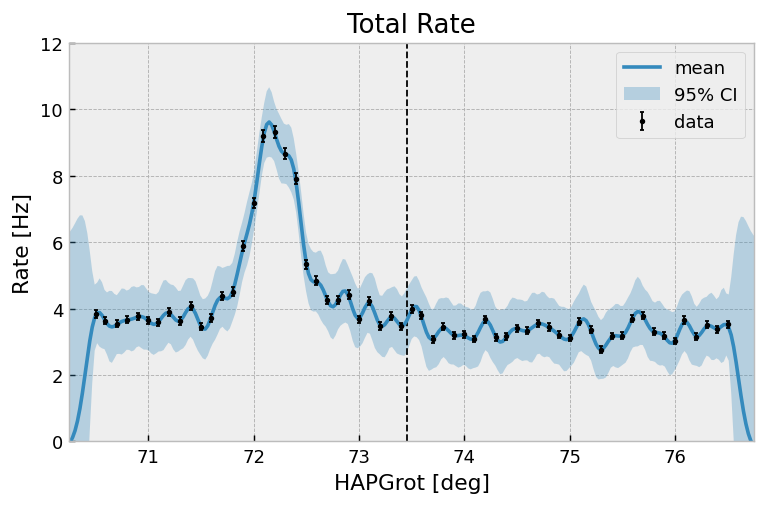

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=False)
likelihood_score.append(fit_estimation(model, likelihood))

visualize_GP(model, likelihood)

  0%|          | 0/500 [00:00<?, ?it/s]

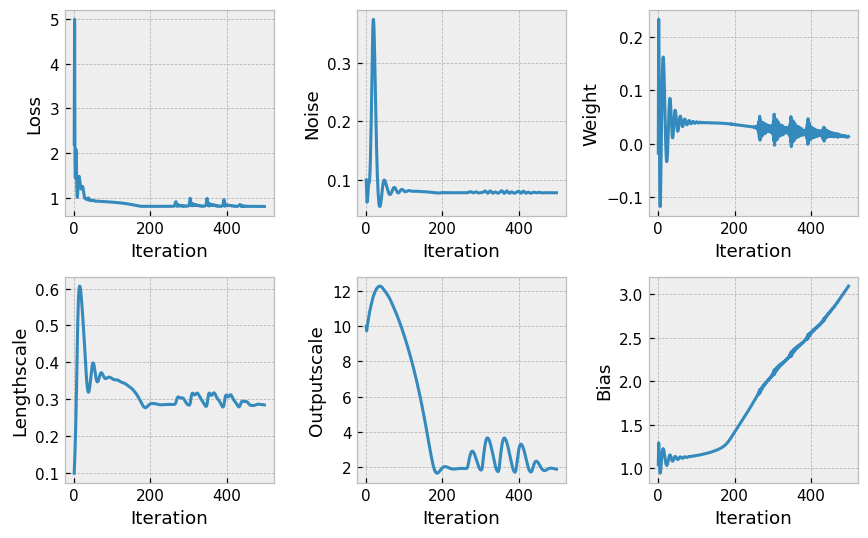

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=True, plot_train=True, training_iter=500)


Likelihood score =  -0.8058701


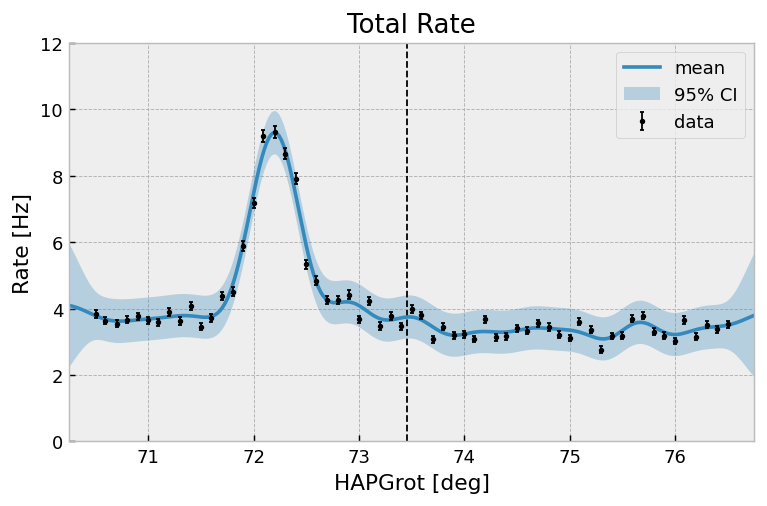

In [ ]:
visualize_GP(model, likelihood)
trained_likelihood_score.append(fit_estimation(model, likelihood))

# 5-GP Quadratic Mean + RBF Kernel #

In [ ]:
class QuadraticMean(gpytorch.means.Mean):
  def __init__(self, batch_shape=torch.Size(), bias=True):
    super().__init__()
    self.register_parameter(
      name="second",
      parameter=torch.nn.Parameter(torch.randn(*batch_shape, 1, 1))
    )

    self.register_parameter(
      name="first",
      parameter=torch.nn.Parameter(torch.randn(*batch_shape, 1, 1))
    )

    if bias:
      self.register_parameter(
        name="bias",
        parameter=torch.nn.Parameter(torch.randn(*batch_shape, 1))
      )
    else:
      self.bias = None

  def forward(self, x):
    res = x.pow(2).matmul(self.second).squeeze(-1) \
        + x.matmul(self.first).squeeze(-1)
    if self.bias is not None:
      res = res + self.bias
    return res

In [ ]:
class QuadraticGPModel(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = QuadraticMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_GP(model, likelihood, training_iter=200):
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam([
        {'params': model.covar_module.parameters()},
        {'params': model.likelihood.parameters()},
        {'params': model.mean_module.parameters()}
    ], lr=0.25)

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    lengthscales = []
    outputscales = []
    noises = []
    weights = []
    biases = []

    for i in tqdm(range(training_iter)):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x) #####
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()

        losses.append(loss.item())
        lengthscales.append(model.covar_module.base_kernel.lengthscale.item())
        outputscales.append(model.covar_module.outputscale.item())
        noises.append(model.likelihood.noise.item())
        weights.append(model.mean_module.first.item())
        biases.append(model.mean_module.bias.item())

        optimizer.step()

    model.eval()
    likelihood.eval()

    return losses, noises, lengthscales, outputscales, weights, biases

def plot_train_GP(losses, noises, lengthscales, outputscales, weights, biases):

    fig, axes = plt.subplots(figsize=(4*2,2.5*2), nrows=2, ncols=3, dpi=110)

    ax = axes[0,0]
    ax.plot(losses)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

    ax = axes[0,1]
    ax.plot(noises)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise')

    ax = axes[0,2]
    ax.plot(weights)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Weight')

    ax = axes[1,0]
    ax.plot(lengthscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Lengthscale')

    ax = axes[1,1]
    ax.plot(outputscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Outputscale')

    ax = axes[1,2]
    ax.plot(biases)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Bias')

    plt.tight_layout()

def fit_GP(
        train_x,
        train_y,
        train=True,
        plot_train=False,
        training_iter=200):

    noise = 1e-1
    lengthscale = 0.1
    outputscale = 10.

    # initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = QuadraticGPModel(train_x, train_y, likelihood)
    model.likelihood.noise = noise

    # Fix the hyperparameters
    model.covar_module.base_kernel.lengthscale = lengthscale
    model.covar_module.outputscale = outputscale

    model.eval()
    likelihood.eval()

    if train:
        losses, noises, lengthscales, outputscales, weights, biases = train_GP(model, likelihood, training_iter)
        if plot_train:
            plot_train_GP(losses, noises, lengthscales, outputscales, weights, biases)

    return model, likelihood

Likelihood score =  -13.895095


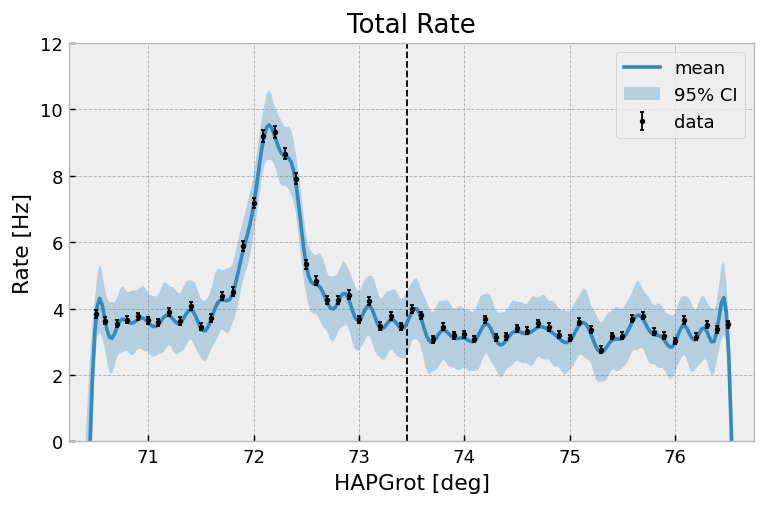

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=False)
likelihood_score.append(fit_estimation(model, likelihood))

visualize_GP(model, likelihood)

  0%|          | 0/200 [00:00<?, ?it/s]

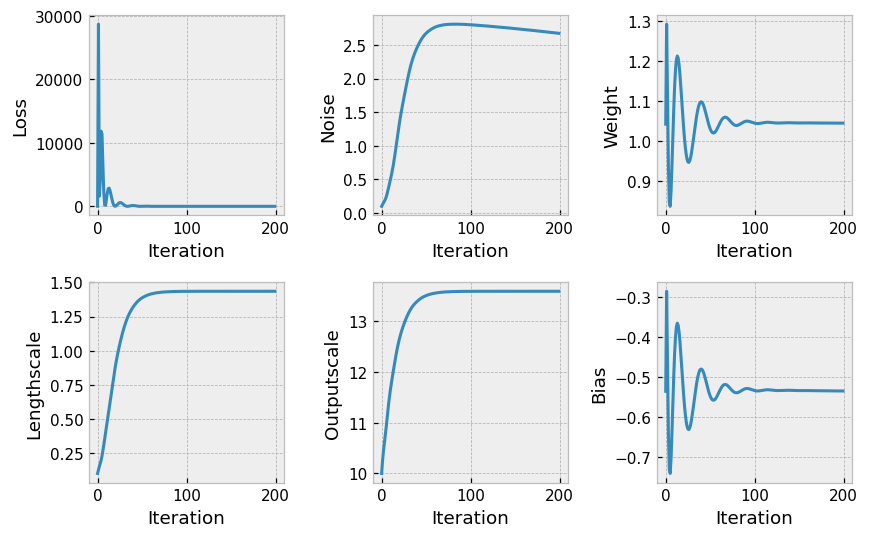

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=True, plot_train=True, training_iter=200)

Likelihood score =  -1.7533526


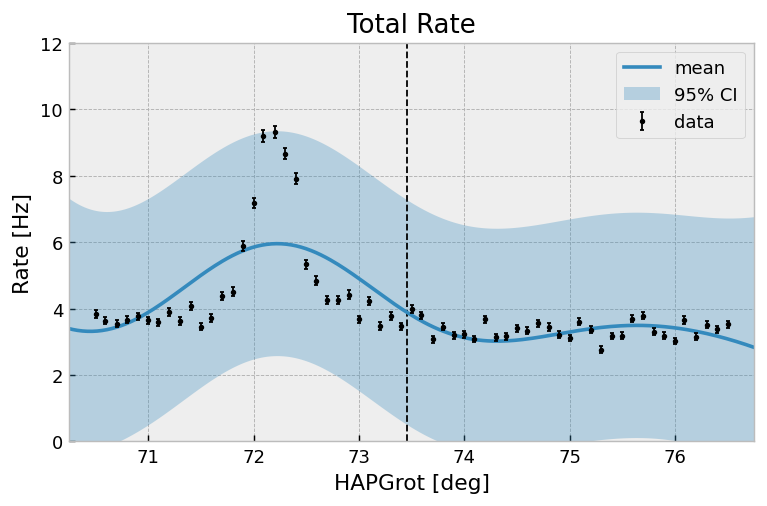

In [ ]:
visualize_GP(model, likelihood)
trained_likelihood_score.append(fit_estimation(model, likelihood))

# 6-GP Constant Mean + Matern Kernel

In [ ]:
class MaternGPModel(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood, nu):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.MaternKernel(nu)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_GP(model, likelihood, training_iter=200):
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam([
        {'params': model.covar_module.parameters()},
        {'params': model.likelihood.parameters()},
        {'params': model.mean_module.constant}
    ], lr=0.25)

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    lengthscales = []
    outputscales = []
    noises = []
    constants = []

    for i in tqdm(range(training_iter)):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()

        losses.append(loss.item())
        lengthscales.append(model.covar_module.lengthscale.item())
        outputscales.append(model.covar_module.outputscale)
        noises.append(model.likelihood.noise.item())
        constants.append(model.mean_module.constant.item())

        optimizer.step()

    model.eval()
    likelihood.eval()

    return losses, noises, lengthscales, outputscales, constants

def plot_train_GP(losses, noises, lengthscales, outputscales, constants):

    fig, axes = plt.subplots(figsize=(4*2,2.5*2), nrows=2, ncols=3, dpi=110)

    ax = axes[0,0]
    ax.plot(losses)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

    ax = axes[0,1]
    ax.plot(noises)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise')

    ax = axes[1,0]
    ax.plot(lengthscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Lengthscale')

    ax = axes[1,1]
    ax.plot(outputscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Outputscale')

    ax = axes[1,2]
    ax.plot(constants)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Constant')

    plt.tight_layout()

def fit_GP(
        train_x,
        train_y,
        train=True,
        plot_train=False,
        training_iter=200):

    noise = 1e-1
    lengthscale = 0.1
    outputscale = 10.

    # initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = MaternGPModel(train_x, train_y, likelihood, 0.5)
    model.likelihood.noise = noise

    # Fix the hyperparameters
    model.covar_module.lengthscale = lengthscale
    model.covar_module.outputscale = outputscale

    model.eval()
    likelihood.eval()

    if train:
        losses, noises, lengthscales, outputscales, constants = train_GP(model, likelihood, training_iter)
        if plot_train:
            plot_train_GP(losses, noises, lengthscales, outputscales, constants)

    return model, likelihood

Likelihood score =  -5.123209


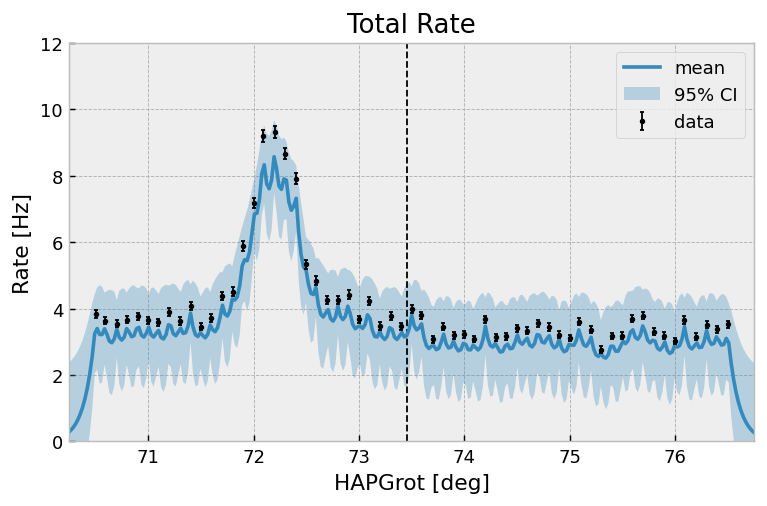

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=False)
likelihood_score.append(fit_estimation(model, likelihood))

visualize_GP(model, likelihood)

  0%|          | 0/200 [00:00<?, ?it/s]

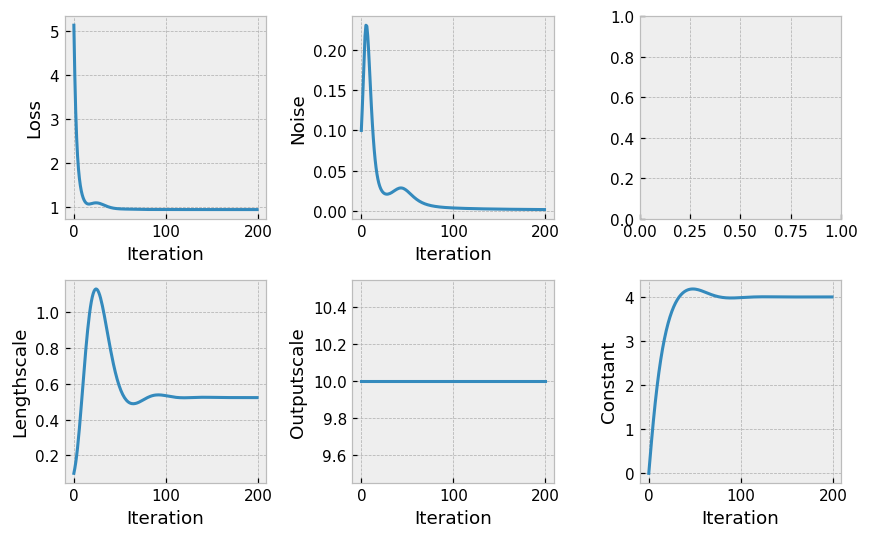

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=True, plot_train=True, training_iter=200)

Likelihood score =  -0.95281744


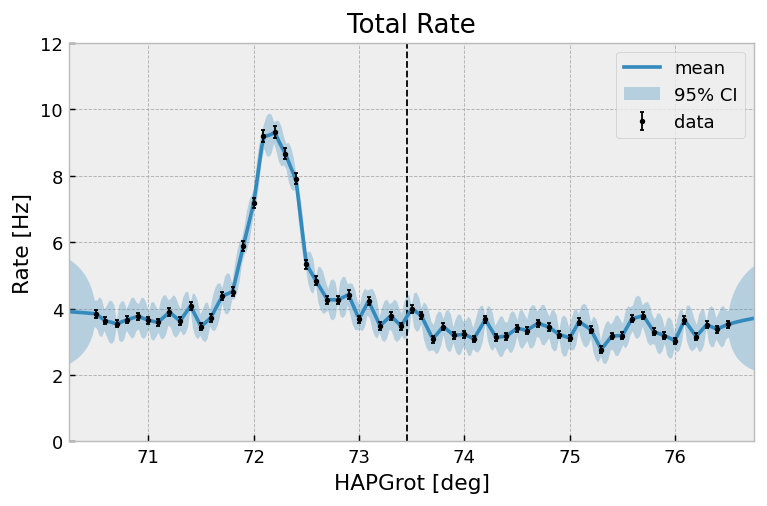

In [ ]:
visualize_GP(model, likelihood)
trained_likelihood_score.append(fit_estimation(model, likelihood))

# 7-GP Constant Mean + Spectral Kernel #

In [ ]:
class SpectralGPModel(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
        self.covar_module.initialize_from_data(train_x, train_y)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_GP(model, likelihood, training_iter=200):
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam([
        {'params': model.covar_module.parameters()},
        {'params': model.likelihood.parameters()},
        {'params': model.mean_module.constant}
    ], lr=0.25)

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    outputscales = []
    noises = []
    constants = []

    for i in tqdm(range(training_iter)):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()

        losses.append(loss.item())
        outputscales.append(model.covar_module.outputscale)
        noises.append(model.likelihood.noise.item())
        constants.append(model.mean_module.constant.item())

        optimizer.step()

    model.eval()
    likelihood.eval()

    return losses, noises, outputscales, constants

def plot_train_GP(losses, noises, outputscales, constants):

    fig, axes = plt.subplots(figsize=(4*2,2.5*2), nrows=2, ncols=2, dpi=110)

    ax = axes[0,0]
    ax.plot(losses)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

    ax = axes[0,1]
    ax.plot(noises)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise')

    ax = axes[1,1]
    ax.plot(outputscales)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Outputscale')

    ax = axes[1,0]
    ax.plot(constants)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Constant')

    plt.tight_layout()

def fit_GP(
        train_x,
        train_y,
        train=True,
        plot_train=False,
        training_iter=200):

    noise = 1e-1
    outputscale = 10.

    # initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = SpectralGPModel(train_x, train_y, likelihood)
    model.likelihood.noise = noise

    # Fix the hyperparameters
    model.covar_module.outputscale = outputscale

    model.eval()
    likelihood.eval()

    if train:
        losses, noises, outputscales, constants = train_GP(model, likelihood, training_iter)
        if plot_train:
            plot_train_GP(losses, noises, outputscales, constants)

    return model, likelihood

Likelihood score =  -15.809714


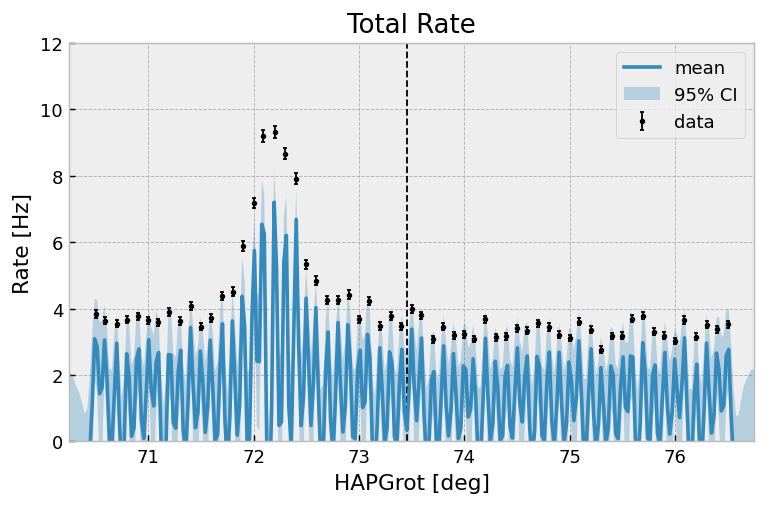

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=False)
likelihood_score.append(fit_estimation(model, likelihood))

visualize_GP(model, likelihood)

  0%|          | 0/200 [00:00<?, ?it/s]

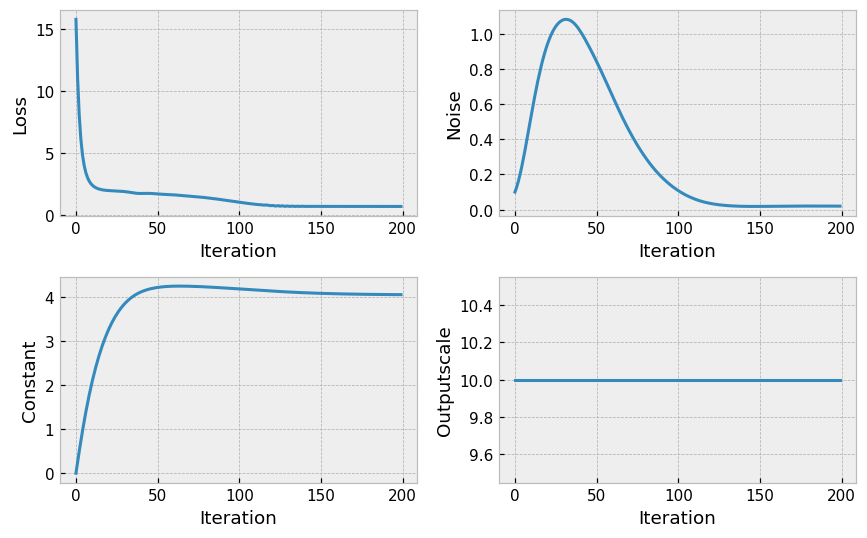

In [ ]:
model, likelihood = fit_GP(train_x, train_y, train=True, plot_train=True, training_iter=200)

Likelihood score =  -0.7110443


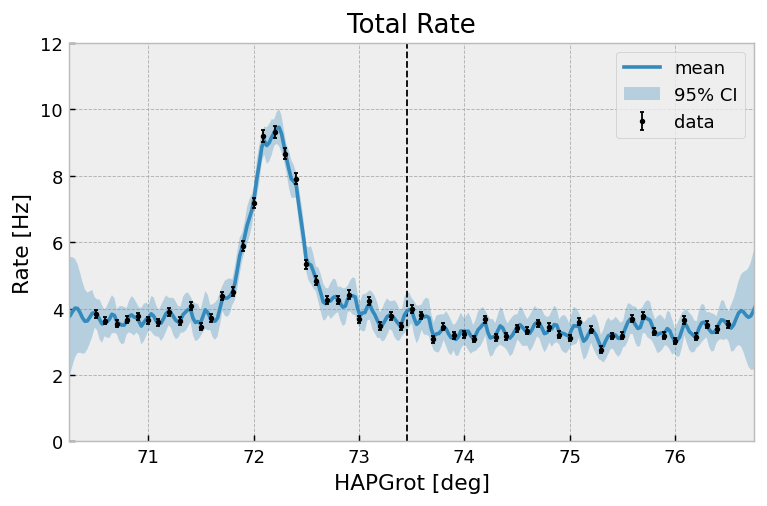

In [ ]:
visualize_GP(model, likelihood)
trained_likelihood_score.append(fit_estimation(model, likelihood))

# Model Comparison #

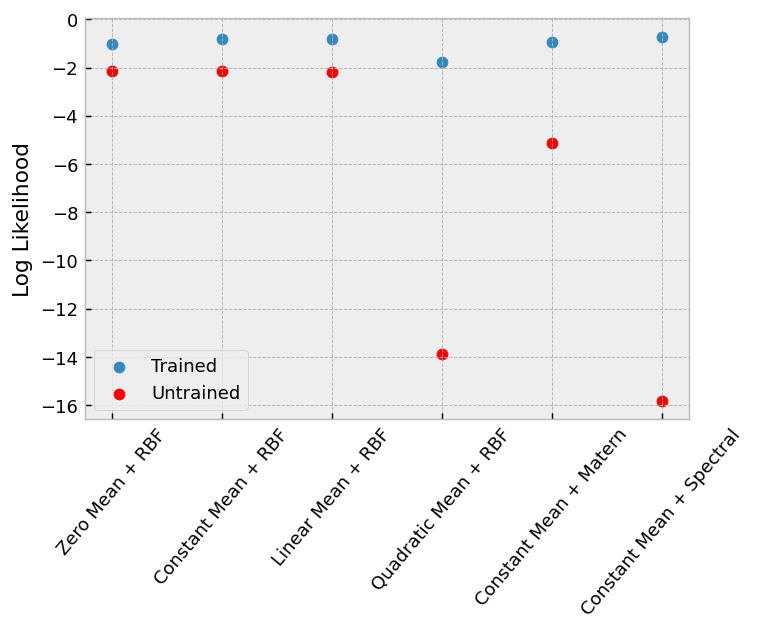

In [ ]:
fig, ax = plt.subplots(figsize=(6,4), nrows=1, ncols=1, dpi=130)

ax.scatter(range(6), trained_likelihood_score, label = 'Trained')
ax.scatter(range(6), likelihood_score, color = 'r', label = 'Untrained')

ax.set_ylabel('Log Likelihood')
#ax.set_ylim(-0.130,-0.065)
ax.set_xticks(range(6))
_ = ax.set_xticklabels(['Zero Mean + RBF', 'Constant Mean + RBF', 'Linear Mean + RBF', 'Quadratic Mean + RBF', 'Constant Mean + Matern', 'Constant Mean + Spectral'], rotation= 50)
ax.legend()

In [ ]:
trained_likelihood_score

[array(-1.007, dtype=float32),
 array(-0.805, dtype=float32),
 array(-0.806, dtype=float32),
 array(-1.753, dtype=float32),
 array(-0.953, dtype=float32),
 array(-0.711, dtype=float32)]